## ResNet50 Classification on New kmax Dataset

This section trains a ResNet50 classifier with a **discrete output vector** over `k_max` classes (no regression).

In [1]:
from pathlib import Path
import json
import time

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

candidate_files = [
    Path('../../data/raw/randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5'),
    Path('../../data/raw/randomboth_uniformkmax_kmin1-16_kmax2-64_128x128_32000.h5'),
    Path('../../data/raw/randomkmax_1-32_128x128_32000.h5'),
    Path('../../data/raw/randomboth_kmin1-16_kmax2-64_128x128_32000.h5'),
]

DATA_FILE = next((p for p in candidate_files if p.exists()), None)
OUTPUT_DIR = Path('../../outputs/pytorch_resnet/kmax_classification')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 200
EARLY_STOP_PATIENCE = 12

if DATA_FILE is None:
    checked = '\n  - '.join(str(p.resolve()) for p in candidate_files)
    raise FileNotFoundError(f'Could not find a kmax dataset. Checked:\n  - {checked}')

with h5py.File(DATA_FILE, 'r') as f:
    n_images = int(f['images'].shape[0])
    kmax_values = f['parameters']['k_max'][:].astype(np.float32)

kmax_labels = np.rint(kmax_values).astype(np.int32)
unique_labels = np.unique(kmax_labels)
label_to_idx = {int(label): idx for idx, label in enumerate(unique_labels.tolist())}
idx_to_label = {idx: int(label) for label, idx in label_to_idx.items()}
class_indices = np.array([label_to_idx[int(v)] for v in kmax_labels], dtype=np.int64)
NUM_CLASSES = int(unique_labels.shape[0])

print(f'Dataset: {DATA_FILE.name}')
print(f'Num images: {n_images}')
print(f'k_max continuous range: {float(kmax_values.min()):.3f} -> {float(kmax_values.max()):.3f}')
print(f'Discrete k_max labels: {int(unique_labels.min())} -> {int(unique_labels.max())} ({NUM_CLASSES} classes)')

all_idx = np.arange(n_images)


def robust_split(indices, y_labels, test_size, random_state):
    unique, counts = np.unique(y_labels, return_counts=True)
    if np.all(counts >= 2):
        return train_test_split(
            indices,
            test_size=test_size,
            random_state=random_state,
            stratify=y_labels,
        )
    return train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=None,
    )


idx_train, idx_temp = robust_split(all_idx, class_indices, test_size=0.30, random_state=SEED)
idx_val, idx_test = robust_split(idx_temp, class_indices[idx_temp], test_size=0.50, random_state=SEED)

print(f'Split sizes -> train: {len(idx_train)}, val: {len(idx_val)}, test: {len(idx_test)}')


class KmaxH5Dataset(Dataset):
    def __init__(self, file_path, indices, class_indices, augment=False):
        self.file_path = str(file_path)
        self.indices = np.asarray(indices, dtype=np.int64)
        self.class_indices = np.asarray(class_indices, dtype=np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        img_idx = int(self.indices[item])
        with h5py.File(self.file_path, 'r') as f:
            img = f['images'][img_idx]

        image = img.astype(np.float32) / 255.0
        image = np.stack([image, image, image], axis=0)
        image = torch.from_numpy(image)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                image = torch.flip(image, dims=(1,))
            if torch.rand(1).item() < 0.5:
                image = torch.flip(image, dims=(2,))

        target_class_idx = torch.tensor(int(self.class_indices[img_idx]), dtype=torch.long)
        return image, target_class_idx


train_dataset = KmaxH5Dataset(DATA_FILE, idx_train, class_indices, augment=True)
val_dataset = KmaxH5Dataset(DATA_FILE, idx_val, class_indices, augment=False)
test_dataset = KmaxH5Dataset(DATA_FILE, idx_test, class_indices, augment=False)

train_class_indices = class_indices[idx_train]
train_class_counts = np.bincount(train_class_indices, minlength=NUM_CLASSES).astype(np.float32)
imbalance_ratio = float(train_class_counts.max() / np.maximum(train_class_counts.min(), 1.0))

class_weights_np = 1.0 / np.sqrt(np.maximum(train_class_counts, 1.0))
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)

sample_weights = class_weights_np[train_class_indices]
train_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
print(f'Train class imbalance ratio (max/min): {imbalance_ratio:.2f}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Dataset: randomboth_balancedkmax_kmin1-16_kmax2-64_128x128_32000.h5
Num images: 32000
k_max continuous range: 4.000 -> 64.000
Discrete k_max labels: 4 -> 64 (61 classes)
Split sizes -> train: 22400, val: 4800, test: 4800
Train batches: 700 | Val batches: 150 | Test batches: 150
Train class imbalance ratio (max/min): 1.00


In [2]:
class ResNet50KmaxClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


model = ResNet50KmaxClassifier(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

# Explicitly train all parameters (no frozen backbone)
for param in model.parameters():
    param.requires_grad = True

num_total_params = sum(p.numel() for p in model.parameters())
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {num_trainable_params:,} / {num_total_params:,}')

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), label_smoothing=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-6
)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_top1 = 0
    total_top3 = 0
    total_count = 0

    with torch.set_grad_enabled(is_train):
        for images, targets in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = loss_fn(logits, targets)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            batch_count = targets.size(0)
            preds_top1 = torch.argmax(logits, dim=1)
            preds_top3 = torch.topk(logits, k=min(3, NUM_CLASSES), dim=1).indices

            total_loss += loss.item() * batch_count
            total_top1 += (preds_top1 == targets).sum().item()
            total_top3 += (preds_top3 == targets.unsqueeze(1)).any(dim=1).sum().item()
            total_count += batch_count

    avg_loss = total_loss / max(total_count, 1)
    top1_acc = total_top1 / max(total_count, 1)
    top3_acc = total_top3 / max(total_count, 1)
    return float(avg_loss), float(top1_acc), float(top3_acc)


history = {
    'train_loss': [], 'train_top1_acc': [], 'train_top3_acc': [],
    'val_loss': [], 'val_top1_acc': [], 'val_top3_acc': [],
}

best_val_top1 = -1.0
best_val_loss = float('inf')
patience_counter = 0

print(f'\nTraining ResNet50 classifier for discrete k_max labels ({NUM_CLASSES} classes, {EPOCHS} epochs max)')
start_time = time.time()

for epoch in range(EPOCHS):
    train_loss, train_top1, train_top3 = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_top1, val_top3 = run_epoch(model, val_loader, optimizer=None)

    scheduler.step(val_top1)

    history['train_loss'].append(train_loss)
    history['train_top1_acc'].append(train_top1)
    history['train_top3_acc'].append(train_top3)
    history['val_loss'].append(val_loss)
    history['val_top1_acc'].append(val_top1)
    history['val_top3_acc'].append(val_top3)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f} top1: {train_top1:.4f} top3: {train_top3:.4f} | "
        f"Val loss: {val_loss:.4f} top1: {val_top1:.4f} top3: {val_top3:.4f}"
    )

    improved = (val_top1 > best_val_top1) or (np.isclose(val_top1, best_val_top1) and val_loss < best_val_loss)
    if improved:
        best_val_top1 = val_top1
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model_kmax_classifier.pth')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'Early stopping at epoch {epoch + 1}')
            break

elapsed = time.time() - start_time
print(f'\nTraining complete in {elapsed / 60:.1f} minutes')

with open(OUTPUT_DIR / 'history_kmax_classifier.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'Saved history to: {OUTPUT_DIR / "history_kmax_classifier.json"}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/davas/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [02:01<00:00, 843kB/s]  
/tmp/ipykernel_18359/2125796248.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Trainable parameters: 24,048,765 / 24,048,765

Training ResNet50 classifier for discrete k_max labels (61 classes, 200 epochs max)


Epoch 01/200 | Train loss: 3.7725 top1: 0.0667 top3: 0.1686 | Val loss: 3.2964 top1: 0.0956 top3: 0.2515


Epoch 02/200 | Train loss: 3.2372 top1: 0.1135 top3: 0.2875 | Val loss: 2.9435 top1: 0.1412 top3: 0.3638


...

Epoch 29/200 | Train loss: 1.1526 top1: 0.7940 top3: 0.9422 | Val loss: 2.8374 top1: 0.2235 top3: 0.5267


Epoch 30/200 | Train loss: 1.1406 top1: 0.7967 top3: 0.9440 | Val loss: 2.8378 top1: 0.2192 top3: 0.5212


Epoch 31/200 | Train loss: 1.1421 top1: 0.7981 top3: 0.9432 | Val loss: 2.8527 top1: 0.2273 top3: 0.5192


Epoch 32/200 | Train loss: 1.1308 top1: 0.7992 top3: 0.9449 | Val loss: 2.8582 top1: 0.2208 top3: 0.5212


Epoch 33/200 | Train loss: 1.1149 top1: 0.8072 top3: 0.9496 | Val loss: 2.8436 top1: 0.2219 top3: 0.5262
Early stopping at epoch 33

Training complete in 46.8 minutes
Saved history to: ../../outputs/pytorch_resnet/kmax_classification/history_kmax_classifier.json


In [3]:
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model_kmax_classifier.pth', map_location=DEVICE))
model.eval()

all_pred_idx = []
all_true_idx = []
top1_correct = 0
top3_correct = 0
n_total = 0

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='Test inference', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        logits = model(images)
        pred_idx = torch.argmax(logits, dim=1)
        pred_top3 = torch.topk(logits, k=min(3, NUM_CLASSES), dim=1).indices

        all_pred_idx.append(pred_idx.detach().cpu().numpy())
        all_true_idx.append(targets.detach().cpu().numpy())

        top1_correct += (pred_idx == targets).sum().item()
        top3_correct += (pred_top3 == targets.unsqueeze(1)).any(dim=1).sum().item()
        n_total += targets.size(0)

pred_idx = np.concatenate(all_pred_idx).astype(np.int64)
true_idx = np.concatenate(all_true_idx).astype(np.int64)

pred_labels = np.array([idx_to_label[int(i)] for i in pred_idx], dtype=np.int32)
true_labels = np.array([idx_to_label[int(i)] for i in true_idx], dtype=np.int32)

top1_acc = float(top1_correct / max(n_total, 1))
top3_acc = float(top3_correct / max(n_total, 1))

metrics = {
    'top1_acc': top1_acc,
    'top3_acc': top3_acc,
    'n_test': int(n_total),
    'num_classes': int(NUM_CLASSES),
}

print('Test metrics (k_max classification):')
for key, value in metrics.items():
    if key in ('n_test', 'num_classes'):
        print(f'  {key}: {value}')
    else:
        print(f'  {key}: {value:.4f}')

with open(OUTPUT_DIR / 'test_metrics_kmax_classifier.json', 'w') as f:
    json.dump(metrics, f, indent=2)

np.savez_compressed(
    OUTPUT_DIR / 'test_predictions_kmax_classifier.npz',
    pred_idx=pred_idx,
    true_idx=true_idx,
    pred_labels=pred_labels,
    true_labels=true_labels,
)

print(f'Saved metrics to: {OUTPUT_DIR / "test_metrics_kmax_classifier.json"}')
print(f'Saved predictions to: {OUTPUT_DIR / "test_predictions_kmax_classifier.npz"}')

Test metrics (k_max classification):
  top1_acc: 0.2219
  top3_acc: 0.5292
  n_test: 4800
  num_classes: 61
Saved metrics to: ../../outputs/pytorch_resnet/kmax_classification/test_metrics_kmax_classifier.json
Saved predictions to: ../../outputs/pytorch_resnet/kmax_classification/test_predictions_kmax_classifier.npz


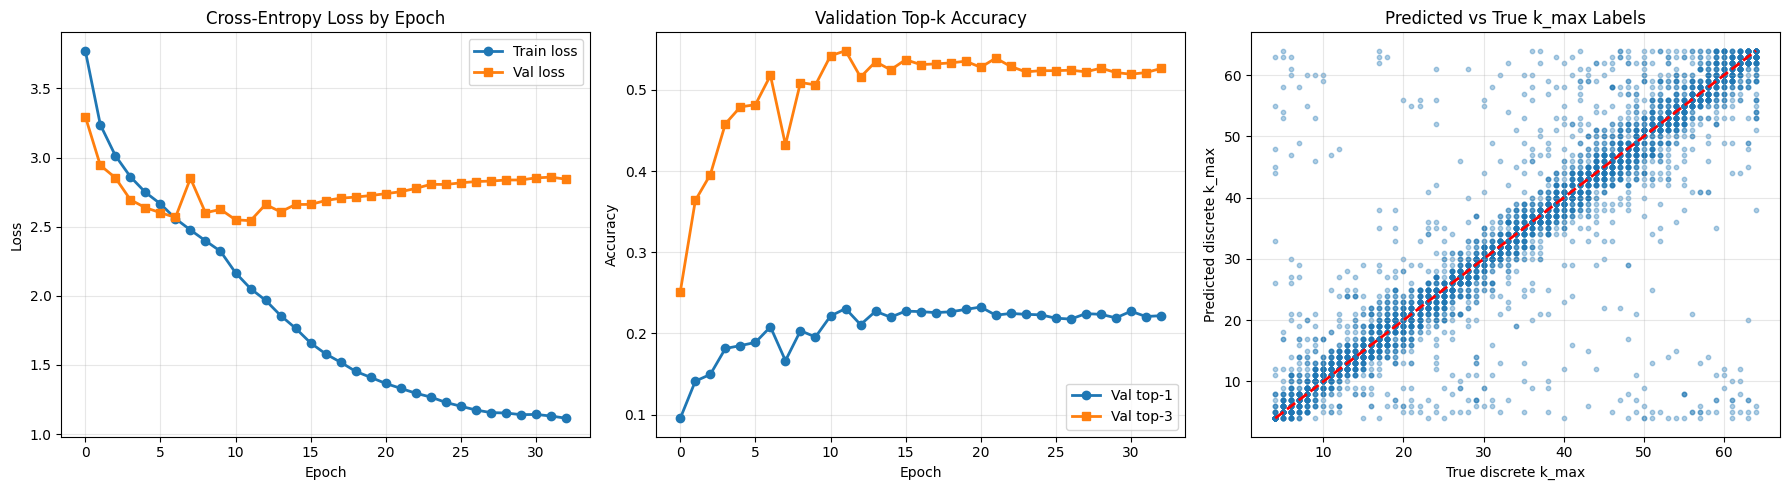

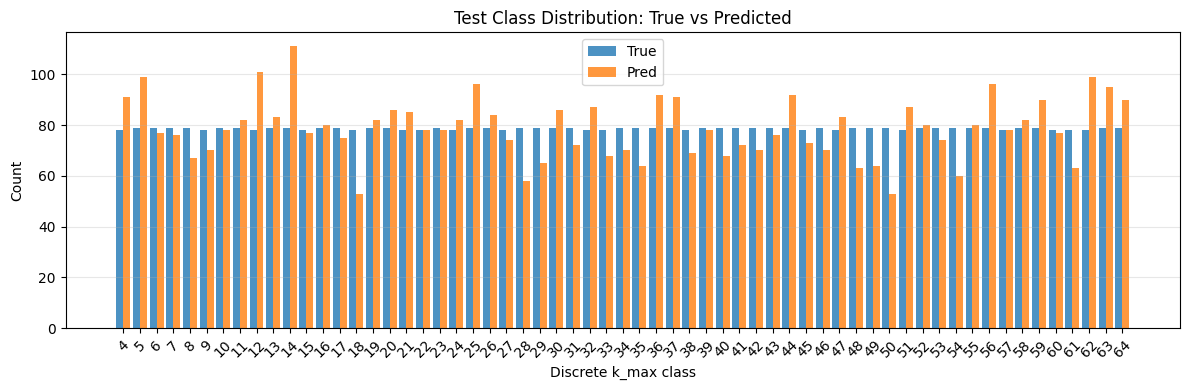

Saved plots to: ../../outputs/pytorch_resnet/kmax_classification


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(history['train_loss'], label='Train loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val loss', marker='s', linewidth=2)
axes[0].set_title('Cross-Entropy Loss by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Top-k accuracy curves
axes[1].plot(history['val_top1_acc'], label='Val top-1', marker='o', linewidth=2)
axes[1].plot(history['val_top3_acc'], label='Val top-3', marker='s', linewidth=2)
axes[1].set_title('Validation Top-k Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Predicted vs true labels
axes[2].scatter(true_labels, pred_labels, s=10, alpha=0.35)
label_min = int(min(true_labels.min(), pred_labels.min()))
label_max = int(max(true_labels.max(), pred_labels.max()))
axes[2].plot([label_min, label_max], [label_min, label_max], 'r--', linewidth=2)
axes[2].set_title('Predicted vs True k_max Labels')
axes[2].set_xlabel('True discrete k_max')
axes[2].set_ylabel('Predicted discrete k_max')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmax_classification_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Class-frequency comparison
plt.figure(figsize=(12, 4))
all_classes = np.array(sorted(set(true_labels.tolist()) | set(pred_labels.tolist())), dtype=np.int32)
true_counts = np.array([(true_labels == c).sum() for c in all_classes], dtype=np.int32)
pred_counts = np.array([(pred_labels == c).sum() for c in all_classes], dtype=np.int32)

width = 0.42
xpos = np.arange(len(all_classes))
plt.bar(xpos - width / 2, true_counts, width=width, label='True', alpha=0.8)
plt.bar(xpos + width / 2, pred_counts, width=width, label='Pred', alpha=0.8)
plt.xticks(xpos, all_classes, rotation=45)
plt.xlabel('Discrete k_max class')
plt.ylabel('Count')
plt.title('Test Class Distribution: True vs Predicted')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'kmax_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved plots to: {OUTPUT_DIR}')

In [5]:
# Quick distribution check: full dataset vs test split (discrete k_max labels)
import numpy as np
import h5py

with h5py.File(DATA_FILE, 'r') as f:
    all_kmax = np.rint(f['parameters']['k_max'][:].astype(np.float32)).astype(np.int32)

all_labels, all_counts = np.unique(all_kmax, return_counts=True)

test_kmax = np.array([idx_to_label[int(i)] for i in class_indices[idx_test]], dtype=np.int32)
test_labels, test_counts = np.unique(test_kmax, return_counts=True)

all_count_map = {int(k): int(v) for k, v in zip(all_labels, all_counts)}
test_count_map = {int(k): int(v) for k, v in zip(test_labels, test_counts)}

print('kmax label | full_count | full_% | test_count | test_%')
for k in sorted(all_count_map.keys()):
    fc = all_count_map[k]
    tc = test_count_map.get(k, 0)
    fp = 100.0 * fc / len(all_kmax)
    tp = 100.0 * tc / len(test_kmax)
    print(f'{k:10d} | {fc:10d} | {fp:6.2f}% | {tc:10d} | {tp:6.2f}%')

print('\nLow-end summary (kmax <= 10):')
low_full = int(sum(v for k, v in all_count_map.items() if k <= 10))
low_test = int(sum(v for k, v in test_count_map.items() if k <= 10))
print(f'  Full: {low_full}/{len(all_kmax)} ({100.0*low_full/len(all_kmax):.2f}%)')
print(f'  Test: {low_test}/{len(test_kmax)} ({100.0*low_test/len(test_kmax):.2f}%)')

kmax label | full_count | full_% | test_count | test_%
         4 |        525 |   1.64% |         78 |   1.62%
         5 |        525 |   1.64% |         79 |   1.65%
         6 |        525 |   1.64% |         79 |   1.65%
         7 |        525 |   1.64% |         79 |   1.65%
         8 |        525 |   1.64% |         79 |   1.65%
         9 |        525 |   1.64% |         78 |   1.62%
        10 |        525 |   1.64% |         79 |   1.65%
        11 |        524 |   1.64% |         79 |   1.65%
        12 |        524 |   1.64% |         78 |   1.62%
        13 |        525 |   1.64% |         79 |   1.65%
        14 |        525 |   1.64% |         79 |   1.65%
        15 |        524 |   1.64% |         78 |   1.62%
        16 |        525 |   1.64% |         79 |   1.65%
        17 |        524 |   1.64% |         79 |   1.65%
        18 |        524 |   1.64% |         78 |   1.62%
        19 |        525 |   1.64% |         79 |   1.65%
        20 |        525 |   1.64%